In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [2]:
from cartpole import CartPole, remap_angle

STATE_NAMES = [
    "x",
    "x_dot",
    "theta",
    "theta_dot",
]

STATE_LABELS = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]

DELTA_NAMES = [
    "Delta x",
    "Delta x_dot",
    "Delta theta",
    "Delta theta_dot",
]

system = CartPole(visual=False)

print("Default state:", system.getState())
print("delta_time:", system.delta_time)
print("sim_steps:", system.sim_steps)

Default state: [0.         0.         3.14159265 0.        ]
delta_time: 0.1
sim_steps: 50


In [3]:
def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path

In [4]:
def one_step_zero_force(initial_state):
    """
    Run exactly one performAction(0.0) call from a given initial state.

    Returns:
        x0:      initial state, shape (4,)
        x_next:  next state, shape (4,)
        delta_x: x_next - x0, shape (4,)
    """
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()

    delta_x = x_next - x0

    return x0, x_next, delta_x

In [5]:
def sample_random_states(num_samples, seed=0):
    """
    Sample random CartPole states from sensible ranges.

    Returns:
        states shape: (num_samples, 4)
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(-5.0, 5.0, size=num_samples)
    x_dot = rng.uniform(-10.0, 10.0, size=num_samples)
    theta = rng.uniform(-np.pi, np.pi, size=num_samples)
    theta_dot = rng.uniform(-15.0, 15.0, size=num_samples)

    states = np.column_stack([x, x_dot, theta, theta_dot])

    return states

In [6]:
N = 500

X_initial = sample_random_states(N, seed=1)

X_next = np.zeros_like(X_initial)
Delta_X = np.zeros_like(X_initial)

for i in range(N):
    x0, x_next, delta_x = one_step_zero_force(X_initial[i])

    X_initial[i] = x0
    X_next[i] = x_next
    Delta_X[i] = delta_x

print("X_initial shape:", X_initial.shape)
print("X_next shape:", X_next.shape)
print("Delta_X shape:", Delta_X.shape)

print("\nFirst 5 X_initial:")
print(X_initial[:5])

print("\nFirst 5 Delta_X:")
print(Delta_X[:5])

X_initial shape: (500, 4)
X_next shape: (500, 4)
Delta_X shape: (500, 4)

First 5 X_initial:
[[ 0.11821625 -1.56792885  0.26594525  3.21800666]
 [ 4.50463696 -9.48865802  2.93979847 11.38004362]
 [-3.55840387 -6.64037058  1.286686    0.48689698]
 [ 4.48649447  4.98921652  0.28415836  3.37769327]
 [-1.88168548 -8.31990464 -0.22823659  6.45491681]]

First 5 Delta_X:
[[-0.16129986 -0.07704247  0.3894885   1.4575189 ]
 [-0.96816941 -0.6743468   1.06182087 -2.65576543]
 [-0.66687526 -0.02207353  0.19621809  2.88896584]
 [ 0.49472872 -0.06674128  0.40774948  1.4978865 ]
 [-0.83199353  0.02694472  0.64178621  0.15263572]]


In [7]:
dataset_path = DATA_DIR / "task1_3_linear_model_dataset_500.npz"

np.savez(
    dataset_path,
    X_initial=X_initial,
    X_next=X_next,
    Delta_X=Delta_X,
)

print("Saved dataset to:", dataset_path)

Saved dataset to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_3_linear_model_dataset_500.npz


In [8]:
def make_linear_features(states, use_intercept=True):
    """
    Construct linear features from state.

    states shape: (N, 4)
    if use_intercept:
        Phi shape: (N, 5), columns [x, x_dot, theta, theta_dot, 1]
    else:
        Phi shape: (N, 4)
    """
    states = np.asarray(states)

    if use_intercept:
        ones = np.ones(states.shape[0])
        Phi = np.column_stack([states, ones])
    else:
        Phi = states.copy()

    return Phi

In [9]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X_initial[train_idx]
Y_train = Delta_X[train_idx]

X_val = X_initial[val_idx]
Y_val = Delta_X[val_idx]

X_test = X_initial[test_idx]
Y_test = Delta_X[test_idx]

Phi_train = make_linear_features(X_train, use_intercept=True)
Phi_val = make_linear_features(X_val, use_intercept=True)
Phi_test = make_linear_features(X_test, use_intercept=True)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("Phi_train shape:", Phi_train.shape)

print("\nX_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)
print("Phi_val shape:", Phi_val.shape)

print("\nX_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)
print("Phi_test shape:", Phi_test.shape)

X_train shape: (300, 4)
Y_train shape: (300, 4)
Phi_train shape: (300, 5)

X_val shape: (100, 4)
Y_val shape: (100, 4)
Phi_val shape: (100, 5)

X_test shape: (100, 4)
Y_test shape: (100, 4)
Phi_test shape: (100, 5)


In [10]:
W_hat, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_train,
    Y_train,
    rcond=None
)

print("W_hat shape:", W_hat.shape)
print("residuals:", residuals)
print("rank:", rank)
print("singular_values:", singular_values)

print("\nW_hat:")
print(W_hat)

W_hat shape: (5, 4)
residuals: [5.63961969e-01 2.17929793e+02 2.79542235e+00 1.25520649e+03]
rank: 5
singular_values: [155.65741019 101.63051416  48.61533339  30.95257636  17.26888143]

W_hat:
[[-1.10228654e-03 -1.59637243e-02 -1.67688677e-03 -2.60155979e-02]
 [ 9.98194967e-02 -5.85497437e-04 -7.03354077e-04 -1.13752866e-02]
 [ 1.51362861e-02  2.39234444e-01  5.25461658e-02  8.87157231e-01]
 [ 1.02016707e-03  2.43795827e-02  1.00735088e-01  1.41892857e-02]
 [ 6.64343589e-04  1.91852265e-02 -5.20081092e-04 -2.28422366e-02]]


In [11]:
def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)


def mse_per_dimension(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2, axis=0)

In [12]:
Y_pred_train = Phi_train @ W_hat
Y_pred_val = Phi_val @ W_hat
Y_pred_test = Phi_test @ W_hat

train_mse = mse(Y_train, Y_pred_train)
val_mse = mse(Y_val, Y_pred_val)
test_mse = mse(Y_test, Y_pred_test)

train_mse_per_dim = mse_per_dimension(Y_train, Y_pred_train)
val_mse_per_dim = mse_per_dimension(Y_val, Y_pred_val)
test_mse_per_dim = mse_per_dimension(Y_test, Y_pred_test)

print("Overall MSE:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

print("\nMSE per dimension [Delta x, Delta x_dot, Delta theta, Delta theta_dot]:")
print("Train:", train_mse_per_dim)
print("Validation:", val_mse_per_dim)
print("Test:", test_mse_per_dim)

Overall MSE:
Train MSE: 1.230413055292663
Validation MSE: 0.7256468317024138
Test MSE: 0.8560540630529533

MSE per dimension [Delta x, Delta x_dot, Delta theta, Delta theta_dot]:
Train: [1.87987323e-03 7.26432644e-01 9.31807450e-03 4.18402163e+00]
Validation: [1.16846332e-03 4.16829920e-01 5.46652123e-03 2.47912242e+00]
Test: [1.16196057e-03 4.18426278e-01 7.03542014e-03 2.99759259e+00]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_3_prediction_vs_truth_test.png


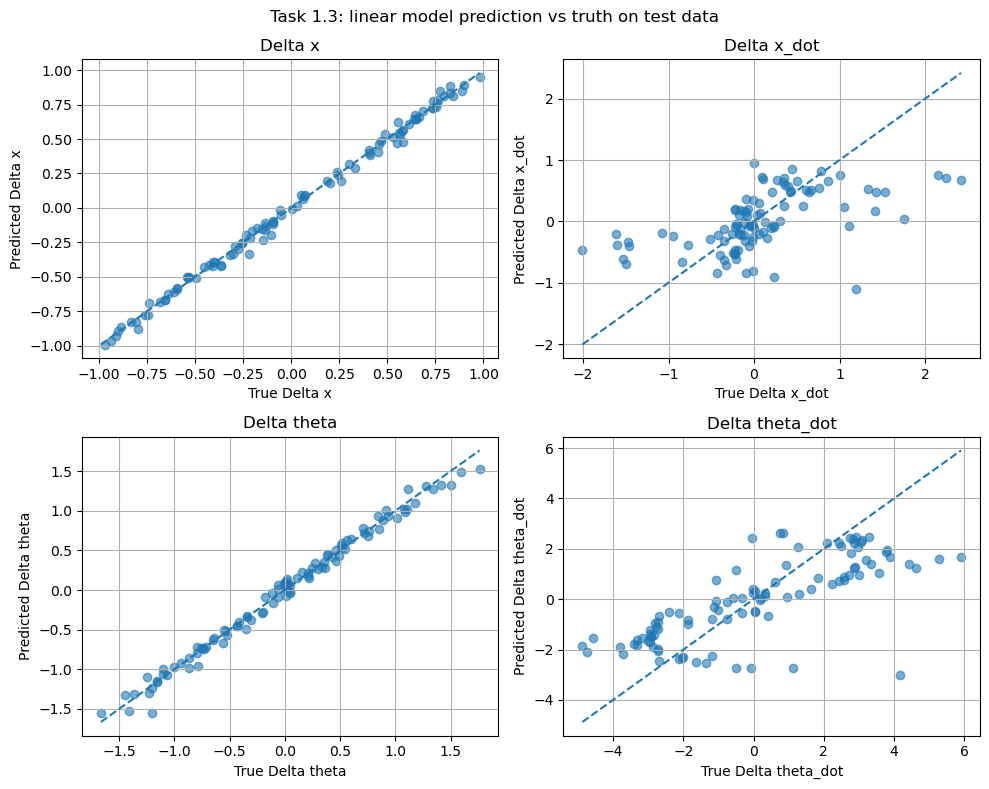

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for dim in range(4):
    ax = axes[dim]

    y_true = Y_test[:, dim]
    y_pred = Y_pred_test[:, dim]

    ax.scatter(y_true, y_pred, alpha=0.6)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        label="perfect prediction",
    )

    ax.set_xlabel(f"True {DELTA_NAMES[dim]}")
    ax.set_ylabel(f"Predicted {DELTA_NAMES[dim]}")
    ax.set_title(DELTA_NAMES[dim])
    ax.grid(True)

fig.suptitle("Task 1.3: linear model prediction vs truth on test data")
fig.tight_layout()

save_figure(fig, "sf3_task1_3_prediction_vs_truth_test.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_3_trajectory_prediction_comparison.png


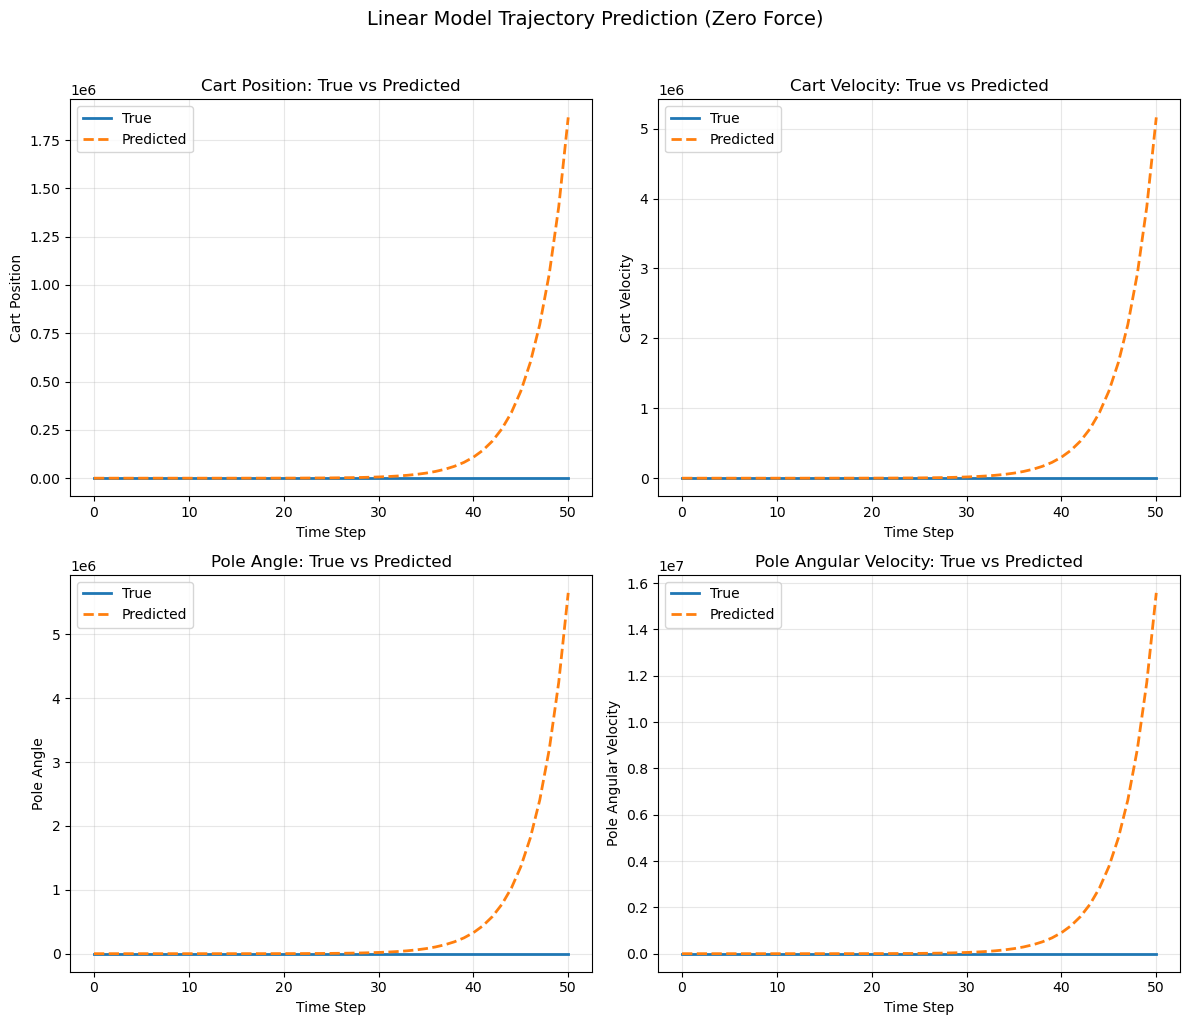

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from cartpole import CartPole

# --------------------------
# 1. 生成真实轨迹（零力控制）
# --------------------------
def generate_true_trajectory(initial_state, num_steps=100):
    """生成真实CartPole系统的零力控制轨迹"""
    env = CartPole(visual=False)  # 关闭可视化加速
    env.setState(initial_state)
    
    true_traj = [initial_state.copy()]
    
    for _ in range(num_steps):
        env.performAction(action=0.0)  # 零力，让系统自然演化
        true_traj.append(env.getState().copy())
    
    return np.array(true_traj)

# --------------------------
# 2. 用线性模型预测轨迹（开环预测）
# --------------------------
def predict_linear_trajectory(initial_state, W_hat, num_steps=100):
    """用训练好的线性模型W_hat预测轨迹（开环）"""
    pred_traj = [initial_state.copy()]
    current_state = initial_state.copy()
    
    for _ in range(num_steps):
        # 构建线性特征（和训练时一致）
        phi = make_linear_features(current_state[None, :], use_intercept=True)
        # 预测状态变化量Δx
        delta_pred = (phi @ W_hat)[0]
        # 更新状态
        current_state = current_state + delta_pred
        pred_traj.append(current_state.copy())
    
    return np.array(pred_traj)

# --------------------------
# 3. 生成轨迹并绘图
# --------------------------
# 初始状态（和你之前测试的一致，杆几乎竖直）
initial_state = np.array([0.0, 0.0, np.pi, 12.0])
num_steps = 50  # 预测50步，太长会累积误差

# 生成真实和预测轨迹
true_traj = generate_true_trajectory(initial_state, num_steps)
pred_traj = predict_linear_trajectory(initial_state, W_hat, num_steps)

# 状态名称（和你代码里的STATE_NAMES保持一致）
STATE_NAMES = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Angular Velocity"
]

# 绘制2×2对比图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
time_steps = np.arange(num_steps + 1)

for dim in range(4):
    ax = axes[dim]
    
    # 画真实轨迹（实线）
    ax.plot(time_steps, true_traj[:, dim], label="True", linewidth=2)
    # 画预测轨迹（虚线）
    ax.plot(time_steps, pred_traj[:, dim], label="Predicted", linestyle="--", linewidth=2)
    
    ax.set_xlabel("Time Step")
    ax.set_ylabel(STATE_NAMES[dim])
    ax.set_title(f"{STATE_NAMES[dim]}: True vs Predicted")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Linear Model Trajectory Prediction (Zero Force)", fontsize=14, y=1.02)
fig.tight_layout()

# 保存图片（用你现有的save_figure函数）
save_figure(fig, "sf3_task1_3_trajectory_prediction_comparison.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_3_trajectory_prediction_local_10steps.png


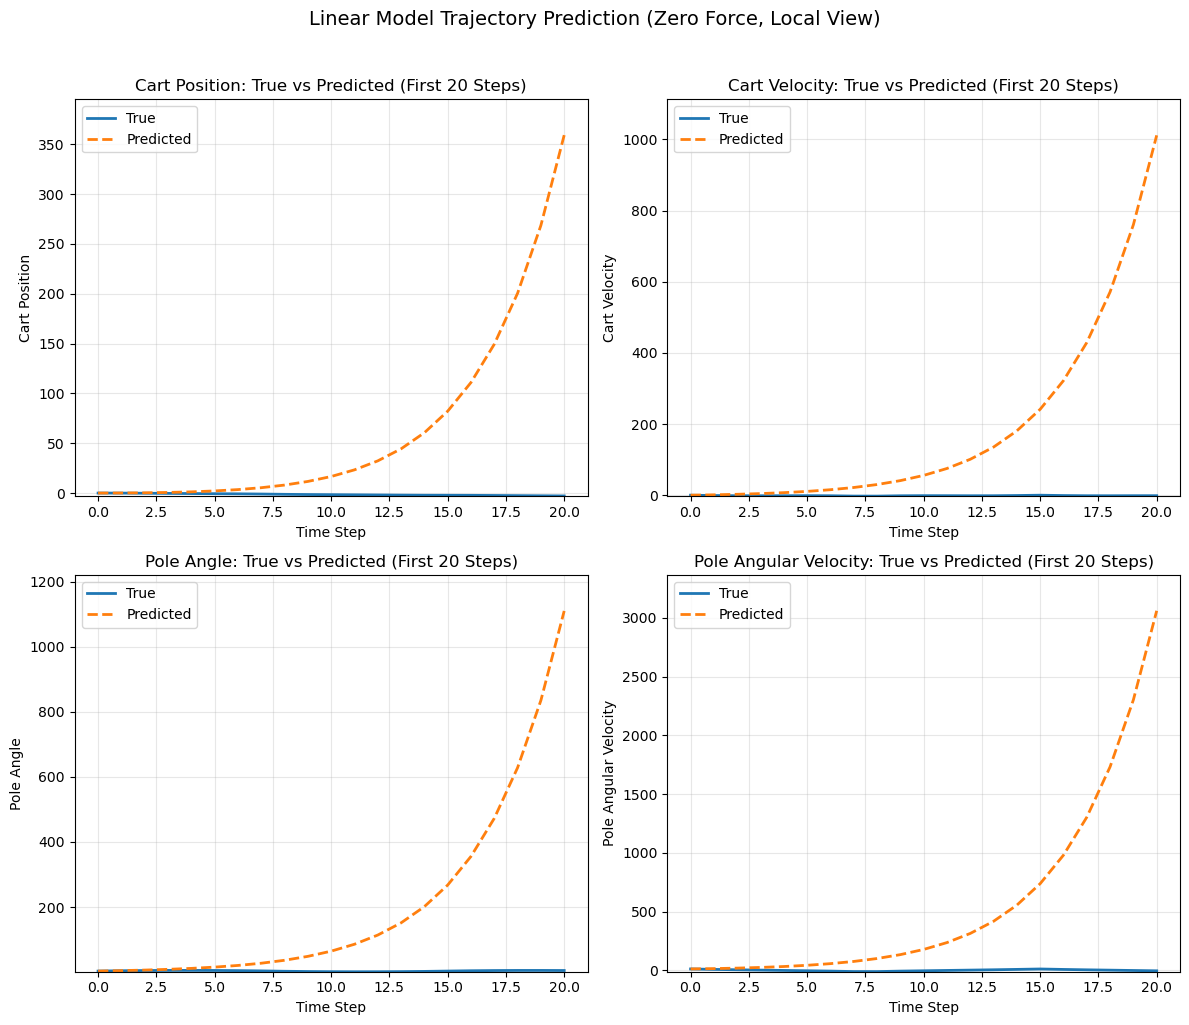

In [15]:
# --------------------------
# 绘制2×2对比图（只显示前N步）
# --------------------------
# 初始状态（和你之前测试的一致，杆几乎竖直）
initial_state = np.array([0.0, 0.0, np.pi, 12.0])
num_steps = 50  # 还是生成50步数据
plot_steps = 20  # ✅ 只显示前40步，改成20/30都可以

# 生成真实和预测轨迹
true_traj = generate_true_trajectory(initial_state, num_steps)
pred_traj = predict_linear_trajectory(initial_state, W_hat, num_steps)

# 状态名称（和你代码里的STATE_NAMES保持一致）
STATE_NAMES = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Angular Velocity"
]

# 绘制2×2对比图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
time_steps = np.arange(num_steps + 1)

# 只取前plot_steps+1个点
time_plot = time_steps[:plot_steps+1]
true_plot = true_traj[:plot_steps+1]
pred_plot = pred_traj[:plot_steps+1]

for dim in range(4):
    ax = axes[dim]
    
    # 画真实轨迹（实线）
    ax.plot(time_plot, true_plot[:, dim], label="True", linewidth=2)
    # 画预测轨迹（虚线）
    ax.plot(time_plot, pred_plot[:, dim], label="Predicted", linestyle="--", linewidth=2)
    
    ax.set_xlabel("Time Step")
    ax.set_ylabel(STATE_NAMES[dim])
    ax.set_title(f"{STATE_NAMES[dim]}: True vs Predicted (First {plot_steps} Steps)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 自动调整y轴范围，只显示前40步的数值范围
    all_values = np.concatenate([true_plot[:, dim], pred_plot[:, dim]])
    ax.set_ylim(all_values.min() * 1.1, all_values.max() * 1.1)

fig.suptitle("Linear Model Trajectory Prediction (Zero Force, Local View)", fontsize=14, y=1.02)
fig.tight_layout()

# 保存图片
save_figure(fig, "sf3_task1_3_trajectory_prediction_local_10steps.png")
plt.show()

In [16]:
base_state = np.array([0.0, 1.0, 0.8, 2.0])

scan_ranges = {
    0: np.linspace(-5.0, 5.0, 121),
    1: np.linspace(-10.0, 10.0, 121),
    2: np.linspace(-np.pi, np.pi, 121),
    3: np.linspace(-15.0, 15.0, 121),
}

In [17]:
def scan_true_and_linear_model(base_state, variable_index, scan_values, W_hat):
    X0_values = []
    Delta_true_values = []
    Delta_pred_values = []

    for value in scan_values:
        state = base_state.copy()
        state[variable_index] = value

        x0, x_next, delta_true = one_step_zero_force(state)

        phi = make_linear_features(x0[None, :], use_intercept=True)
        delta_pred = (phi @ W_hat)[0]

        X0_values.append(x0)
        Delta_true_values.append(delta_true)
        Delta_pred_values.append(delta_pred)

    return (
        np.array(X0_values),
        np.array(Delta_true_values),
        np.array(Delta_pred_values),
    )

In [18]:
def plot_linear_scan_comparison(filename):
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))

    for row, variable_index in enumerate(range(4)):
        scan_values = scan_ranges[variable_index]

        X0_scan, Delta_true, Delta_pred = scan_true_and_linear_model(
            base_state=base_state,
            variable_index=variable_index,
            scan_values=scan_values,
            W_hat=W_hat,
        )

        for col, output_index in enumerate(range(4)):
            ax = axes[row, col]

            ax.plot(scan_values, Delta_true[:, output_index], label="true")
            ax.plot(scan_values, Delta_pred[:, output_index], linestyle="--", label="linear model")

            ax.grid(True)

            if row == 0:
                ax.set_title(f"output: {DELTA_NAMES[output_index]}")

            if col == 0:
                ax.set_ylabel(f"scan {STATE_NAMES[variable_index]}")

            if row == 3:
                ax.set_xlabel(STATE_NAMES[variable_index])

            if row == 0 and col == 0:
                ax.legend()

    fig.suptitle("Task 1.3: true vs linear-model state changes under scans")
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_3_scan_true_vs_linear_model.png


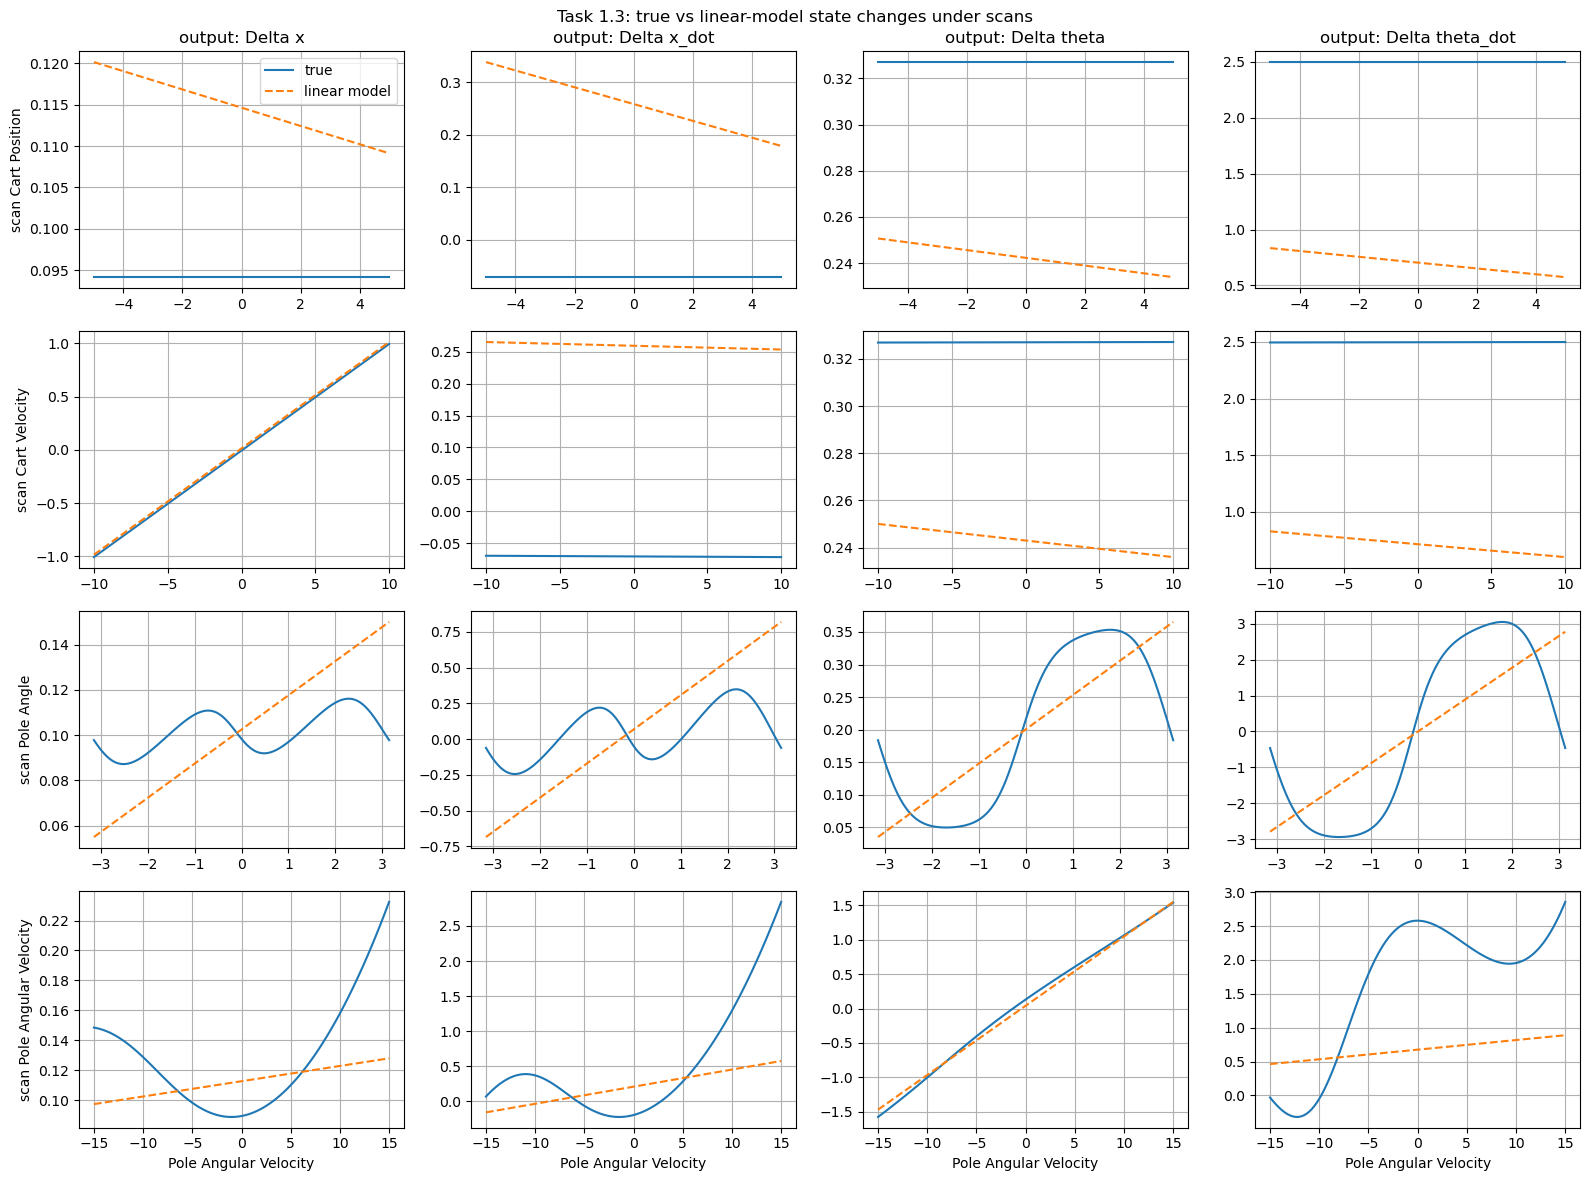

In [19]:
plot_linear_scan_comparison(
    filename="sf3_task1_3_scan_true_vs_linear_model.png"
)